In [31]:
import pandas as pd
import numpy as np
df=pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
cat_col=[col for col in df.columns if df[col].dtype=='object']
num_col=[col for col in df.columns if df[col].dtype!='object']
print('Categorical columns:',cat_col)
print('Numerical columns:',num_col)


Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [34]:
df[cat_col].nunique()

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [35]:
round((df.isnull().sum()/df.shape[0])*100,2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [47]:
df1=df.drop(columns=['PassengerId','Name','Ticket','Cabin'])
df1.dropna(subset=['Embarked'],inplace=True)
df1['Age']=df1['Age'].fillna(df['Age'].mean())
df1.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


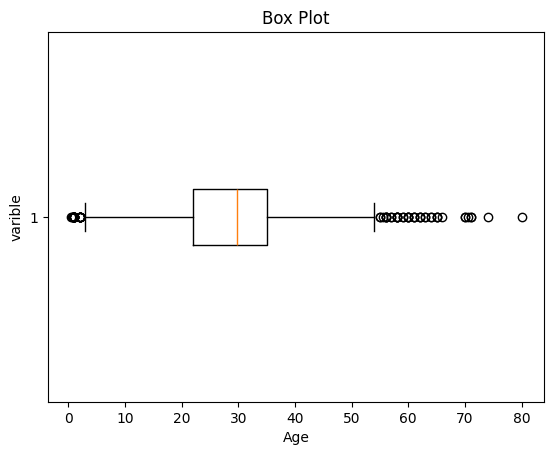

In [48]:
import matplotlib.pyplot as plt
plt.boxplot(df1['Age'],vert=False)
plt.ylabel('varible')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()


In [38]:
mean=df1['Age'].mean()
std=df1['Age'].std()

lower_b=mean-2*std
upper_b=mean+2*std 

df2=df1[(df1['Age']>=lower_b)&(df1['Age']<=upper_b)]


In [39]:
df3=df2.fillna(df2['Age'].mean())
df3.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [40]:
X = df3[['Pclass','Sex','Age', 'SibSp','Parch','Fare','Embarked']]
Y = df3['Survived']


In [41]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
num_col_=[col for col in X.columns if X[col].dtype!='object']
x1=X.copy()
x1[num_col_]=scaler.fit_transform(x1[num_col_])
x1.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1.0,male,0.372057,0.2,0.0,0.014151,S
1,0.0,female,0.651143,0.2,0.0,0.139136,C
2,1.0,female,0.441828,0.0,0.0,0.015469,S
3,0.0,female,0.598814,0.2,0.0,0.103644,S
4,1.0,male,0.598814,0.0,0.0,0.015713,S
